In [ ]:
import os
import gc
import sys
import platform
import hashlib
import random
import math
import json
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
PROJECT_ROOT = Path.cwd() / "MIT805"

DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
WORKING_ROOT = DATA_ROOT / "working"
PROCESSING_ROOT = DATA_ROOT / "processing"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

DATA_SUBDIR = "15_min_interval_stocks"

print()
print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_ROOT)
print("Working data:", WORKING_ROOT)
print("Processing data:", PROCESSING_ROOT)
print("Outputs:", OUTPUT_ROOT)


Project root: C:\Users\LOPEZ\MIT805
Raw data: C:\Users\LOPEZ\MIT805\data\raw
Working data: C:\Users\LOPEZ\MIT805\data\working
Processing data: C:\Users\LOPEZ\MIT805\data\processing
Outputs: C:\Users\LOPEZ\MIT805\outputs


In [ ]:
selected_working_path = (OUTPUT_ROOT / "Selected_Working_Inventory.csv")
working_iventory = pd.read_csv(selected_working_path)

In [ ]:
working_iventory.head(5)

,Unnamed: 0,path,interval_folder,sector,ticker,size_bytes,size_gb
0,0,15_min_interval_stocks/Financials/SAN.csv,15_min_interval_stocks,Financials,SAN,10978331,0.010224
1,1,15_min_interval_stocks/Financials/FNWB.csv,15_min_interval_stocks,Financials,FNWB,1985939,0.001850
2,2,15_min_interval_stocks/Financials/RDN.csv,15_min_interval_stocks,Financials,RDN,10363238,0.009652
3,3,15_min_interval_stocks/Financials/EOS.csv,15_min_interval_stocks,Financials,EOS,7139514,0.006649
4,4,15_min_interval_stocks/Financials/DB.csv,15_min_interval_stocks,Financials,DB,12181371,0.011345


In [ ]:
working_iventory['size_gb'].sum()

12.030780371278372

In [ ]:
raw_size_bytes = working_iventory["size_bytes"].sum()
raw_size_gb = raw_size_bytes / 1024**3

TARGET_PROCESSING_GB = 3.01
sampling_fraction = TARGET_PROCESSING_GB / raw_size_gb

print(f"Raw dataset: {raw_size_gb:.2f} GB")
print(f"Target processing dataset: {TARGET_PROCESSING_GB:.2f} GB")
print(f"Sampling fraction: {sampling_fraction:.2%}")

Raw dataset: 12.03 GB
Target processing dataset: 3.01 GB
Sampling fraction: 25.02%


In [ ]:
sector_summary = (
    working_iventory
    .groupby("sector")
    .agg(ticker_count=("ticker", "nunique"), number_of_files=("path", "count"), total_size_gb=("size_gb", "sum"))
    .reset_index()
)

sector_summary["size_proportion"] = (sector_summary["total_size_gb"] / sector_summary["total_size_gb"].sum())
sector_summary = sector_summary.sort_values("total_size_gb", ascending=False)

sector_summary

,sector,ticker_count,number_of_files,total_size_gb,size_proportion
4,Financials,746,746,2.694114,0.223935
1,Consumer_Discretionary,616,616,2.410605,0.200370
5,Healthcare,598,598,1.615307,0.134265
6,Industrials,289,289,1.405040,0.116787
9,Technology,362,362,1.366305,0.113567
8,Real_Estate,150,150,0.604959,0.050284
3,Energy,93,93,0.484116,0.040240
11,Utilities,94,94,0.447810,0.037222
2,Consumer_Staples,76,76,0.310648,0.025821
0,Basic_Materials,65,65,0.277983,0.023106


In [ ]:
print("Total proportion:", sector_summary["size_proportion"].sum())

display(sector_summary.style.format({"size_gb": "{:.2f}", "size_proportion": "{:.2%}"}))

Total proportion: 1.0


,sector,ticker_count,number_of_files,total_size_gb,size_proportion
4,Financials,746,746,2.694114,22.39%
1,Consumer_Discretionary,616,616,2.410605,20.04%
5,Healthcare,598,598,1.615307,13.43%
6,Industrials,289,289,1.405040,11.68%
9,Technology,362,362,1.366305,11.36%
8,Real_Estate,150,150,0.604959,5.03%
3,Energy,93,93,0.484116,4.02%
11,Utilities,94,94,0.447810,3.72%
2,Consumer_Staples,76,76,0.310648,2.58%
0,Basic_Materials,65,65,0.277983,2.31%


In [ ]:
sector_summary["expected_processing_gb"] = sector_summary["size_proportion"] * TARGET_PROCESSING_GB

display(
    sector_summary[
        [
            "sector",
            "ticker_count",
            "total_size_gb",
            "size_proportion",
            "expected_processing_gb"
        ]
    ].style.format({
        "total_size_gb": "{:.2f}",
        "size_proportion": "{:.2%}",
        "expected_processing_gb": "{:.2f}"
    })
)

,sector,ticker_count,total_size_gb,size_proportion,expected_processing_gb
4,Financials,746,2.69,22.39%,0.67
1,Consumer_Discretionary,616,2.41,20.04%,0.60
5,Healthcare,598,1.62,13.43%,0.40
6,Industrials,289,1.41,11.68%,0.35
9,Technology,362,1.37,11.36%,0.34
8,Real_Estate,150,0.60,5.03%,0.15
3,Energy,93,0.48,4.02%,0.12
11,Utilities,94,0.45,3.72%,0.11
2,Consumer_Staples,76,0.31,2.58%,0.08
0,Basic_Materials,65,0.28,2.31%,0.07


In [ ]:
selected_files = []

for _, row in sector_summary.iterrows():
    sector = row["sector"]

    target_sector_size = row["expected_processing_gb"]
    files_by_sector = working_iventory[working_iventory["sector"] == sector].copy()

    files_by_sector = files_by_sector.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    acc_size = 0

    for _, file_row in files_by_sector.iterrows():
      if acc_size >= target_sector_size:
        break

      selected_files.append(file_row.to_dict())

      acc_size += (file_row["size_gb"])

selected_files_inventory = pd.DataFrame(selected_files)
selected_files_inventory = selected_files_inventory.drop_duplicates(subset=["path"]).reset_index(drop=True)

print(f"Selected Size: {(selected_files_inventory["size_gb"]).sum():.2f} GiB")
print(f"Selected Size: {(selected_files_inventory["size_gb"] * 1.07374182).sum():.2f} GB")

Selected Size: 3.05 GiB
Selected Size: 3.28 GB


In [ ]:
selected_files_inventory

,Unnamed: 0,path,interval_folder,sector,ticker,size_bytes,size_gb
0,208,15_min_interval_stocks/Financials/AMSF.csv,15_min_interval_stocks,Financials,AMSF,6834821,0.006365
1,259,15_min_interval_stocks/Financials/HUT.csv,15_min_interval_stocks,Financials,HUT,2376495,0.002213
2,97,15_min_interval_stocks/Financials/SWKH.csv,15_min_interval_stocks,Financials,SWKH,948289,0.000883
3,148,15_min_interval_stocks/Financials/BRW.csv,15_min_interval_stocks,Financials,BRW,5641890,0.005254
4,395,15_min_interval_stocks/Financials/DHY.csv,15_min_interval_stocks,Financials,DHY,6690020,0.006231
...,...,...,...,...,...,...,...
879,3311,15_min_interval_stocks/Other/BEAGU.csv,15_min_interval_stocks,Other,BEAGU,11682,0.000011
880,3305,15_min_interval_stocks/Other/POLE.csv,15_min_interval_stocks,Other,POLE,9935,0.000009
881,3220,15_min_interval_stocks/Other/YHNAU.csv,15_min_interval_stocks,Other,YHNAU,8816,0.000008
882,3254,15_min_interval_stocks/Other/VFF.csv,15_min_interval_stocks,Other,VFF,2676910,0.002493


In [ ]:
selected_files_inventory.to_csv(OUTPUT_ROOT / "Selected_processing_Inventory.csv")

In [ ]:
selected_sector_summary = (
    selected_files_inventory
    .groupby("sector")
    .agg(ticker_count=("ticker", "nunique"), selected_size_gb=("size_gb", "sum"))
    .reset_index()
)

In [ ]:
selected_sector_summary

,sector,ticker_count,selected_size_gb
0,Basic_Materials,12,0.076492
1,Consumer_Discretionary,176,0.604481
2,Consumer_Staples,23,0.086921
3,Energy,20,0.124860
4,Financials,204,0.676912
5,Healthcare,153,0.404892
6,Industrials,76,0.351635
7,Other,39,0.044515
8,Real_Estate,36,0.151594
9,Technology,100,0.347155


In [ ]:
selected_sector_summary = (
    selected_files_inventory
    .groupby("sector")
    .agg(ticker_count=("ticker", "nunique"), number_of_files=("path", "count"), total_size_gb=("size_gb", "sum"))
    .reset_index()
)

selected_sector_summary["size_proportion"] = (selected_sector_summary["total_size_gb"] / selected_sector_summary["total_size_gb"].sum())
selected_sector_summary = selected_sector_summary.sort_values("total_size_gb", ascending=False)

selected_sector_summary

,sector,ticker_count,number_of_files,total_size_gb,size_proportion
4,Financials,204,204,0.676912,0.221787
1,Consumer_Discretionary,176,176,0.604481,0.198055
5,Healthcare,153,153,0.404892,0.132661
6,Industrials,76,76,0.351635,0.115212
9,Technology,100,100,0.347155,0.113744
8,Real_Estate,36,36,0.151594,0.049669
3,Energy,20,20,0.124860,0.040910
11,Utilities,29,29,0.122423,0.040111
2,Consumer_Staples,23,23,0.086921,0.028479
0,Basic_Materials,12,12,0.076492,0.025062


In [ ]:

from tqdm.auto import tqdm
downloaded_records = []

for _, row in tqdm(selected_files_inventory.iterrows(), total=len(selected_files_inventory), desc="Copying complete ticker files"):
    sector = row["sector"]
    ticker = row["ticker"]

    # Source file in the working dataset
    source_file = WORKING_ROOT / DATA_SUBDIR / sector / f"{ticker}.csv"

    # Destination directory in the processing dataset
    output_dir = PROCESSING_ROOT / DATA_SUBDIR / sector
    output_dir.mkdir(parents=True, exist_ok=True)

    # Destination file
    output_file = output_dir / f"{ticker}.csv"

    # Copy the complete ticker file
    shutil.copy2(source_file, output_file)

    downloaded_records.append({
        "source_path": str(source_file),
        "processing_path": str(output_file),
        "sector": sector,
        "ticker": ticker,
        "size_bytes": row["size_bytes"],
        "size_gb": row["size_gb"]
    })

print(f"Done copying: {len(downloaded_records)} files")

Copying complete ticker files:   0%|          | 0/884 [00:00<?, ?it/s]

Done copying: 884 files


##**PySpark**

In [ ]:
!pip install -q pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
import sys
import pyspark

print("Python version:", sys.version)
print("PySpark version:", pyspark.__version__)

Python version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
PySpark version: 3.5.1


In [ ]:
TABLES_ROOT = OUTPUT_ROOT / "tables"
FIGURES_ROOT = OUTPUT_ROOT / "figures"

TABLES_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
print("Processing files:", len(list(PROCESSING_ROOT.rglob("*.csv"))))

Processing files: 884


In [ ]:
processing_files = list(PROCESSING_ROOT.rglob("*.csv"))

processing_size_bytes = sum(file.stat().st_size for file in processing_files)
processing_size_gb = processing_size_bytes / (1024 ** 3)

print(f"Processing files: {len(processing_files):,}")
print(f"Processing dataset size: {processing_size_gb:.2f} GB")

Processing files: 884
Processing dataset size: 3.05 GB


In [ ]:
PROCESSING_DATASET = PROCESSING_ROOT / DATA_SUBDIR

In [ ]:
try:
    spark.stop()
except:
    pass

print("Spark stopped.")

Spark stopped.


In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MIT805_StockMarket_Analysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.hadoop.io.native.lib.available", "false")
    .config(
        "spark.hadoop.fs.file.impl",
        "org.apache.hadoop.fs.RawLocalFileSystem"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)

Spark version: 3.5.1
Spark master: local[*]


In [ ]:
import os

print("Python:", os.sys.version)
print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)
print("Available CPU cores:", os.cpu_count())

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
Spark: 3.5.1
Master: local[*]
Available CPU cores: 4


In [ ]:
test_file = next(PROCESSING_DATASET.rglob("*.csv"))

print("Testing file:")
print(test_file)

Testing file:
C:\Users\LOPEZ\MIT805\data\processing\15_min_interval_stocks\Basic_Materials\AU.csv


In [ ]:
test_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(test_file))
)

test_df.show(5)

+-------------------+-------+-------+-------+-------+------+
|          timestamp|   open|   high|    low|  close|volume|
+-------------------+-------+-------+-------+-------+------+
|2000-01-03 09:30:00| 17.127| 17.127|17.0431|17.0431|  9000|
|2000-01-03 09:45:00| 17.211| 17.211|17.0851|17.0851|  2300|
|2000-01-03 10:00:00| 17.211| 17.211| 17.211| 17.211|  1100|
|2000-01-03 10:15:00|17.2949|17.2949| 17.253|17.2949|  5000|
|2000-01-03 10:30:00| 17.253| 17.253| 17.253| 17.253|   400|
+-------------------+-------+-------+-------+-------+------+
only showing top 5 rows



In [ ]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv([str(f) for f in processing_files])
)

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
df_raw.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)



In [ ]:
df_raw.show(10, truncate=False)

+-------------------+-------+-------+-------+-------+-------+
|timestamp          |open   |high   |low    |close  |volume |
+-------------------+-------+-------+-------+-------+-------+
|2000-01-03 09:30:00|37.9178|38.2854|37.8872|37.9178|1015400|
|2000-01-03 09:45:00|37.8872|37.9178|37.0909|37.1215|296600 |
|2000-01-03 10:00:00|37.1215|37.489 |37.0602|37.3972|425400 |
|2000-01-03 10:15:00|37.3665|37.4278|36.999 |37.1828|411000 |
|2000-01-03 10:30:00|37.1828|37.244 |36.8765|36.9377|228200 |
|2000-01-03 10:45:00|36.9377|36.999 |36.0801|36.4783|499400 |
|2000-01-03 11:00:00|36.4477|36.6008|36.0189|36.0189|193600 |
|2000-01-03 11:15:00|35.9576|36.1108|35.6513|36.0495|558800 |
|2000-01-03 11:30:00|36.0495|36.5702|35.9883|36.5089|323000 |
|2000-01-03 11:45:00|36.4783|36.754 |36.3558|36.6621|175800 |
+-------------------+-------+-------+-------+-------+-------+
only showing top 10 rows



In [ ]:
print(f"Number of columns: {len(df_raw.columns)}")
print("Columns:", df_raw.columns)

Number of columns: 6
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']


In [ ]:
raw_count = df_raw.count()

print(f"Total observations: {raw_count:,}")

Total observations: 61,438,865


In [ ]:
df = df_raw.withColumn(
    "source_file",
    F.input_file_name()
)

In [ ]:
df = (
    df
    .withColumn(
        "ticker",
        F.regexp_extract(
            "source_file",
            r"([^/\\]+)\.csv$",
            1
        )
    )
    .withColumn(
        "sector",
        F.regexp_extract(
            "source_file",
            r"[/\\]([^/\\]+)[/\\][^/\\]+\.csv$",
            1
        )
    )
)

In [ ]:
df = (
    df
    .withColumn(
        "timestamp",
        F.to_timestamp("timestamp")
    )
    .withColumn("open", F.col("open").cast("double"))
    .withColumn("high", F.col("high").cast("double"))
    .withColumn("low", F.col("low").cast("double"))
    .withColumn("close", F.col("close").cast("double"))
    .withColumn("volume", F.col("volume").cast("double"))
)

In [ ]:
df = df.select(
    "timestamp",
    "sector",
    "ticker",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "source_file"
)

In [ ]:
df_clean = df.filter(
    F.col("timestamp").isNotNull()
    & F.col("sector").isNotNull()
    & F.col("ticker").isNotNull()
    & F.col("close").isNotNull()
    & F.col("volume").isNotNull()
    & (F.col("close") > 0)
    & (F.col("volume") >= 0)
)

In [ ]:
clean_count = df_clean.count()

print(f"Raw observations:     {raw_count:,}")
print(f"Clean observations:   {clean_count:,}")
print(f"Removed observations: {raw_count - clean_count:,}")

Raw observations:     61,438,865
Clean observations:   61,438,865
Removed observations: 0


In [ ]:
window_spec = (
    Window.partitionBy("sector", "ticker").orderBy("timestamp")
)

df_returns = df_clean.withColumn(
    "previous_close", F.lag("close").over(window_spec)
)

In [ ]:
df_returns = df_returns.withColumn(
    "return",
    F.when(
        F.col("previous_close").isNotNull()
        & (F.col("previous_close") != 0),
        (F.col("close") - F.col("previous_close"))
        / F.col("previous_close")
    )
)

In [ ]:
df_returns = df_returns.withColumn(
    "dollar_volume",
    F.col("close") * F.col("volume")
)

In [ ]:
df_returns = (
    df_returns
    .withColumn("date", F.to_date("timestamp"))
    .withColumn("year", F.year("timestamp"))
    .withColumn("month", F.month("timestamp"))
)

In [ ]:
df_returns.select(
    "timestamp",
    "sector",
    "ticker",
    "close",
    "volume",
    "previous_close",
    "return",
    "dollar_volume"
).show(20, truncate=False)

+-------------------+---------------+------+-------+--------+--------------+----------------------+------------------+
|timestamp          |sector         |ticker|close  |volume  |previous_close|return                |dollar_volume     |
+-------------------+---------------+------+-------+--------+--------------+----------------------+------------------+
|2000-01-03 09:30:00|Basic_Materials|IP    |22.3341|353020.0|NULL          |NULL                  |7884383.982       |
|2000-01-03 09:45:00|Basic_Materials|IP    |22.3341|93456.0 |22.3341       |0.0                   |2087255.6496      |
|2000-01-03 10:00:00|Basic_Materials|IP    |22.4576|93350.0 |22.3341       |0.005529660922087747  |2096416.96        |
|2000-01-03 10:15:00|Basic_Materials|IP    |22.507 |61881.0 |22.4576       |0.00219970076945008   |1392755.6670000001|
|2000-01-03 10:30:00|Basic_Materials|IP    |22.4576|78672.0 |22.507        |-0.002194872706269254 |1766784.3072      |
|2000-01-03 10:45:00|Basic_Materials|IP    |22.2

#Shuffle / Grouping

In [ ]:
stock_grouped = (
    df_returns
    .groupBy("sector", "ticker")
)

In [ ]:
stock_grouped.count().explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (8)
+- HashAggregate (7)
   +- Exchange (6)
      +- HashAggregate (5)
         +- Project (4)
            +- Filter (3)
               +- Project (2)
                  +- Scan csv  (1)


(1) Scan csv 
Output [3]: [timestamp#78, close#82, volume#83]
Batched: false
Location: InMemoryFileIndex [file:/C:/Users/LOPEZ/MIT805/data/processing/15_min_interval_stocks/Basic_Materials/AU.csv, ... 883 entries]
ReadSchema: struct<timestamp:timestamp,close:double,volume:int>

(2) Project
Output [4]: [timestamp#78, close#82, volume#83, input_file_name() AS source_file#133]
Input [3]: [timestamp#78, close#82, volume#83]

(3) Filter
Input [4]: [timestamp#78, close#82, volume#83, source_file#133]
Condition : (isnotnull(volume#83) AND ((((isnotnull(timestamp#78) AND isnotnull(close#82)) AND isnotnull(cast(volume#83 as double))) AND (close#82 > 0.0)) AND (volume#83 >= 0)))

(4) Project
Output [2]: [regexp_extract(source_file#133, [/\\]([^/\\]+)[/\\][^/\\]+\.csv$, 1) A

#Reduction / Aggregation

In [ ]:
stock_summary = (
    df_returns
    .groupBy("sector", "ticker")
    .agg(
        F.count("*").alias("observations"),

        F.avg("close").alias("average_close"),
        F.min("close").alias("minimum_close"),
        F.max("close").alias("maximum_close"),
        F.stddev("close").alias("price_stddev"),

        F.avg("volume").alias("average_volume"),
        F.sum("volume").alias("total_volume"),

        F.avg("dollar_volume").alias("average_dollar_volume"),
        F.sum("dollar_volume").alias("total_dollar_volume"),

        F.avg("return").alias("average_return"),
        F.stddev("return").alias("return_volatility")
    )
)

In [ ]:
stock_summary_count = stock_summary.count()

print(f"Number of stocks analysed: {stock_summary_count:,}")

Number of stocks analysed: 884


In [ ]:
stock_summary.orderBy(F.desc("total_volume")).show(10, truncate=False)

+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+---------------------+
|sector                |ticker|observations|average_close     |minimum_close|maximum_close|price_stddev      |average_volume    |total_volume    |average_dollar_volume|total_dollar_volume  |average_return       |return_volatility    |
+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+---------------------+
|Healthcare            |PFE   |263919      |20.837658216725554|5.952        |53.5555      |10.394193967803405|748675.502612544  |1.97589689974E11|1.3737833887324817E7 |3.6256753817088784E12|8.552252063336331E-6 |0.0034465852440003224|
|Financials            |WFC   |251002      |29.8125082051183

In [ ]:
sector_summary = (
    df_returns
    .groupBy("sector")
    .agg(
        F.countDistinct("ticker").alias("number_of_stocks"),
        F.count("*").alias("observations"),

        F.avg("close").alias("average_close"),

        F.avg("volume").alias("average_volume"),
        F.sum("volume").alias("total_volume"),

        F.avg("dollar_volume").alias("average_dollar_volume"),
        F.sum("dollar_volume").alias("total_dollar_volume"),

        F.avg("return").alias("average_return"),
        F.stddev("return").alias("return_volatility")
    )
    .orderBy(F.desc("total_volume"))
)

In [ ]:
sector_summary.count()

12

In [ ]:
sector_summary.show(truncate=False)

+----------------------+----------------+------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+--------------------+
|sector                |number_of_stocks|observations|average_close     |average_volume    |total_volume    |average_dollar_volume|total_dollar_volume  |average_return       |return_volatility   |
+----------------------+----------------+------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+--------------------+
|Consumer_Discretionary|176             |12240801    |213.53433426477508|56943.023097998244|6.97028214081E11|1852290.3215080432   |2.2673517219805977E13|2.2640725779587853E-4|0.35251179357367346 |
|Technology            |100             |7131412     |596.5041818293945 |88730.75494516373 |6.32775570585E11|2469361.8170459466   |1.761003649442327E13 |1.831280328445384E-4 |0.11263533572781649 |
|Financials    

In [ ]:
sector_stock_activity = (
    stock_summary
    .groupBy("sector")
    .agg(
        F.count("*").alias("stocks"),
        F.avg("total_volume").alias("average_stock_total_volume"),
        F.avg("average_volume").alias("average_stock_volume"),
        F.avg("return_volatility").alias("average_stock_volatility")
    )
    .orderBy(F.desc("average_stock_total_volume"))
)

In [ ]:
sector_stock_activity.show(truncate=False)

+----------------------+------+--------------------------+--------------------+------------------------+
|sector                |stocks|average_stock_total_volume|average_stock_volume|average_stock_volatility|
+----------------------+------+--------------------------+--------------------+------------------------+
|Basic_Materials       |12    |1.8148084661583332E10     |86025.98799311717   |0.014760209008388439    |
|Energy                |20    |1.07724629773E10          |64636.128057755785  |0.01602477840166561     |
|Technology            |100   |6.32775570585E9           |46992.14552316073   |0.055089963045342055    |
|Consumer_Staples      |23    |4.315504876608696E9       |38850.79340537977   |0.022392551305187778    |
|Utilities             |29    |4.1521346202413793E9      |27511.65855911617   |0.02029108047331301     |
|Consumer_Discretionary|176   |3.960387580005682E9       |36469.80289040273   |0.06192820707189057     |
|Industrials           |76    |3.576426165144737E9     

In [ ]:
top_volume_stocks = (
    stock_summary
    .orderBy(F.desc("total_volume"))
    .limit(10)
)

top_volume_stocks.show(truncate=False)

+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+---------------------+
|sector                |ticker|observations|average_close     |minimum_close|maximum_close|price_stddev      |average_volume    |total_volume    |average_dollar_volume|total_dollar_volume  |average_return       |return_volatility    |
+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+----------------+---------------------+---------------------+---------------------+---------------------+
|Healthcare            |PFE   |263919      |20.837658216725554|5.952        |53.5555      |10.394193967803405|748675.502612544  |1.97589689974E11|1.3737833887324817E7 |3.6256753817088784E12|8.552252063336331E-6 |0.0034465852440003224|
|Financials            |WFC   |251002      |29.8125082051183

In [ ]:
top_volatility_stocks = (
    stock_summary
    .filter(F.col("return_volatility").isNotNull())
    .orderBy(F.desc("return_volatility"))
    .limit(10)
)

top_volatility_stocks.show(truncate=False)

+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+-------------+---------------------+---------------------+---------------------+------------------+
|sector                |ticker|observations|average_close     |minimum_close|maximum_close|price_stddev      |average_volume    |total_volume |average_dollar_volume|total_dollar_volume  |average_return       |return_volatility |
+----------------------+------+------------+------------------+-------------+-------------+------------------+------------------+-------------+---------------------+---------------------+---------------------+------------------+
|Healthcare            |PRTA  |84109       |32.598582419241815|0.01         |79.5358      |18.90954541129083 |12793.440464159603|1.076043484E9|432054.9298731843    |3.633970809670366E10 |0.04761641010510589  |13.792451879895568|
|Healthcare            |PMCB  |79553       |96.58596989805419 |0.005        |915.275

In [ ]:
sector_summary.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (16)
+- Sort (15)
   +- Exchange (14)
      +- HashAggregate (13)
         +- Exchange (12)
            +- HashAggregate (11)
               +- HashAggregate (10)
                  +- HashAggregate (9)
                     +- Project (8)
                        +- Window (7)
                           +- Sort (6)
                              +- Exchange (5)
                                 +- Project (4)
                                    +- Filter (3)
                                       +- Project (2)
                                          +- Scan csv  (1)


(1) Scan csv 
Output [3]: [timestamp#78, close#82, volume#83]
Batched: false
Location: InMemoryFileIndex [file:/C:/Users/LOPEZ/MIT805/data/processing/15_min_interval_stocks/Basic_Materials/AU.csv, ... 883 entries]
ReadSchema: struct<timestamp:timestamp,close:double,volume:int>

(2) Project
Output [4]: [timestamp#78, close#82, volume#83, input_file_name() AS source_file#133]
Input [3]: 

In [ ]:
sector_pd = sector_summary.toPandas()
sector_pd

,sector,number_of_stocks,observations,average_close,average_volume,total_volume,average_dollar_volume,total_dollar_volume,average_return,return_volatility
0,Consumer_Discretionary,176,12240801,213.534334,56943.023098,6.970282e+11,1.852290e+06,2.267352e+13,0.000226,0.352512
1,Technology,100,7131412,596.504182,88730.754945,6.327756e+11,2.469362e+06,1.761004e+13,0.000183,0.112635
2,Financials,204,13398066,57.636808,32627.436604,4.371445e+11,8.236717e+05,1.103561e+13,0.000084,0.063725
3,Healthcare,153,8637654,5151.595007,50148.540493,4.331657e+11,1.523767e+06,1.316177e+13,0.002068,2.151978
4,Industrials,76,6883893,181.407328,39484.691083,2.718084e+11,1.350185e+06,9.294529e+12,0.000054,0.011201
5,Basic_Materials,12,1480048,21.082025,147141.860223,2.177770e+11,3.029773e+06,4.484210e+12,0.000054,0.011507
6,Energy,20,2416126,1679.455024,89171.367531,2.154493e+11,2.389331e+06,5.772925e+12,0.000046,0.015431
7,Utilities,29,2399434,22.927220,50183.461594,1.204119e+11,1.250217e+06,2.999814e+12,0.000223,0.096978
8,Consumer_Staples,23,1705103,66.477560,58211.505206,9.925661e+10,1.941944e+06,3.311214e+12,0.000128,0.027159
9,Real_Estate,36,2953852,27.609587,27415.773007,8.098214e+10,7.731374e+05,2.283733e+12,0.000049,0.009813


In [ ]:
top_volume_pd = top_volume_stocks.toPandas()
top_volatility_pd = top_volatility_stocks.toPandas()

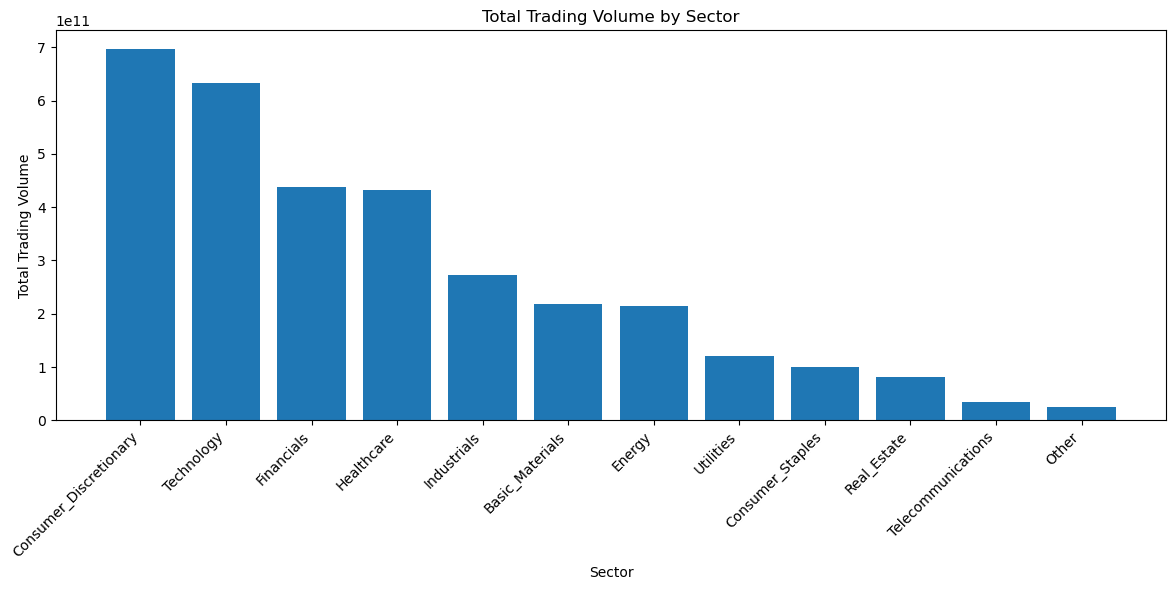

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(sector_pd["sector"], sector_pd["total_volume"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Total Trading Volume")
plt.title("Total Trading Volume by Sector")

plt.tight_layout()
plt.show()

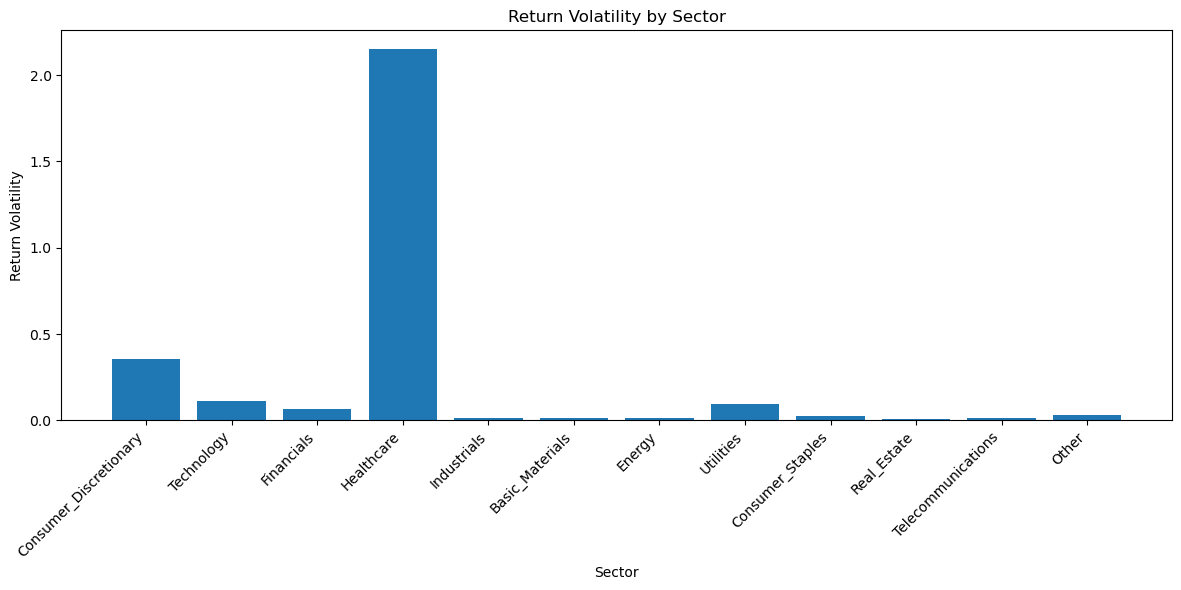

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(sector_pd["sector"], sector_pd["return_volatility"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Return Volatility")
plt.title("Return Volatility by Sector")

plt.tight_layout()
plt.show()

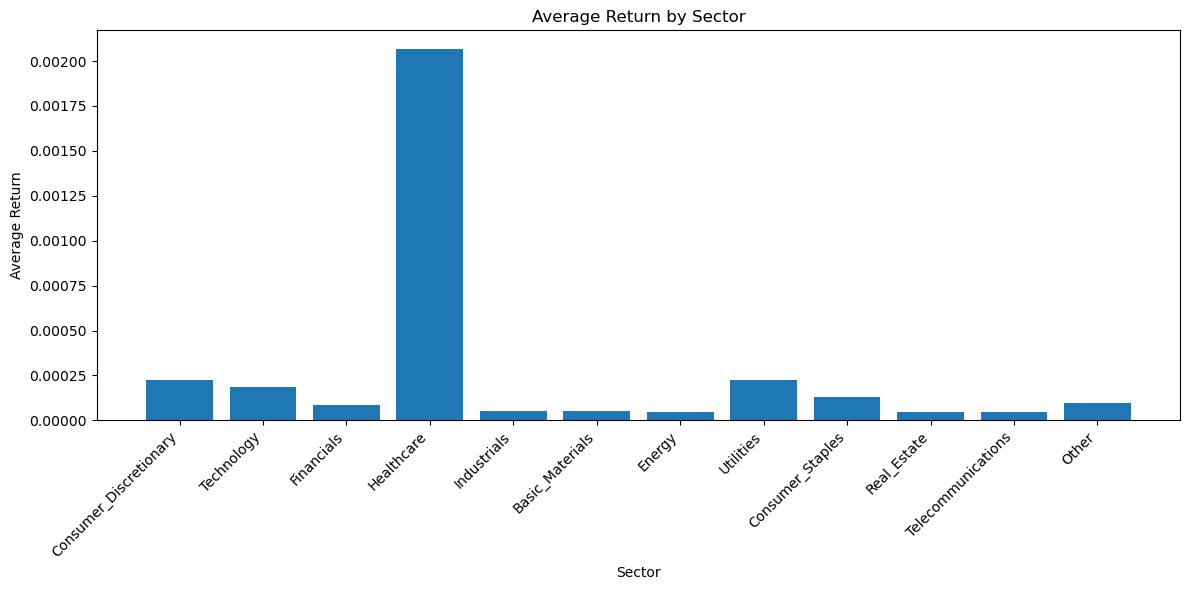

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(sector_pd["sector"], sector_pd["average_return"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Average Return")
plt.title("Average Return by Sector")

plt.tight_layout()
plt.show()

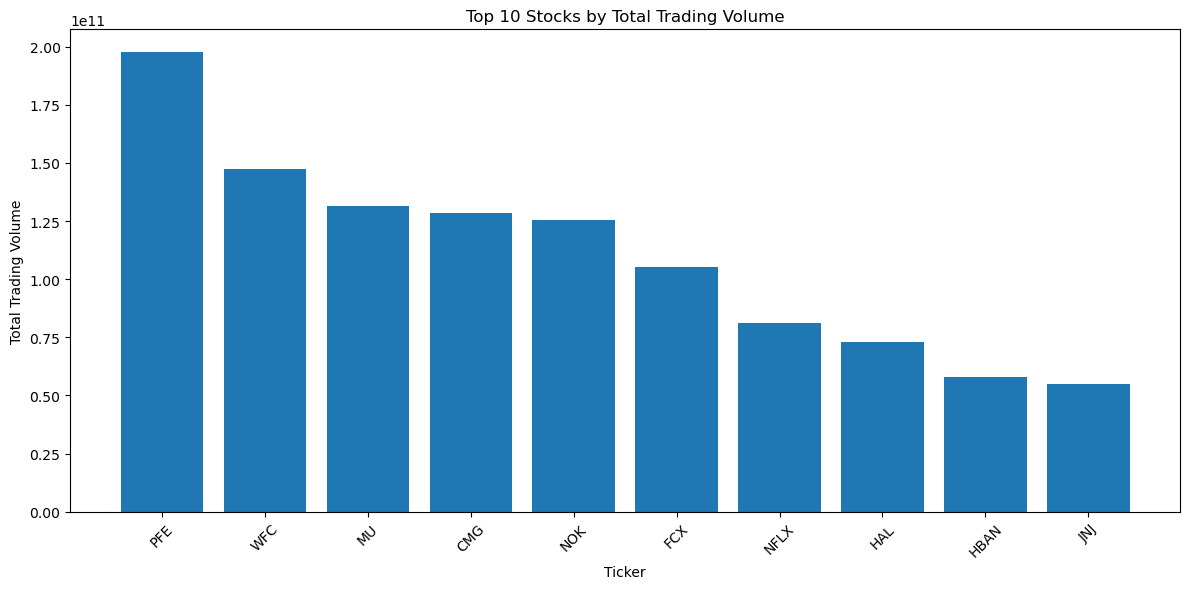

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(top_volume_pd["ticker"], top_volume_pd["total_volume"])

plt.xticks(rotation=45)
plt.xlabel("Ticker")
plt.ylabel("Total Trading Volume")
plt.title("Top 10 Stocks by Total Trading Volume")

plt.tight_layout()
plt.show()

In [ ]:
sector_output = TABLES_ROOT / "sector_summary.csv"

sector_pd.to_csv(sector_output, index=False)

print("Saved:", sector_output)

Saved: C:\Users\LOPEZ\MIT805\outputs\tables\sector_summary.csv


In [ ]:
top_volume_output = TABLES_ROOT / "top_10_volume_stocks.csv"

top_volume_pd.to_csv(top_volume_output, index=False)

top_volatility_output = TABLES_ROOT / "top_10_volatility_stocks.csv"

top_volatility_pd.to_csv(top_volatility_output, index=False)

print("Saved stock-level result tables.")

Saved stock-level result tables.


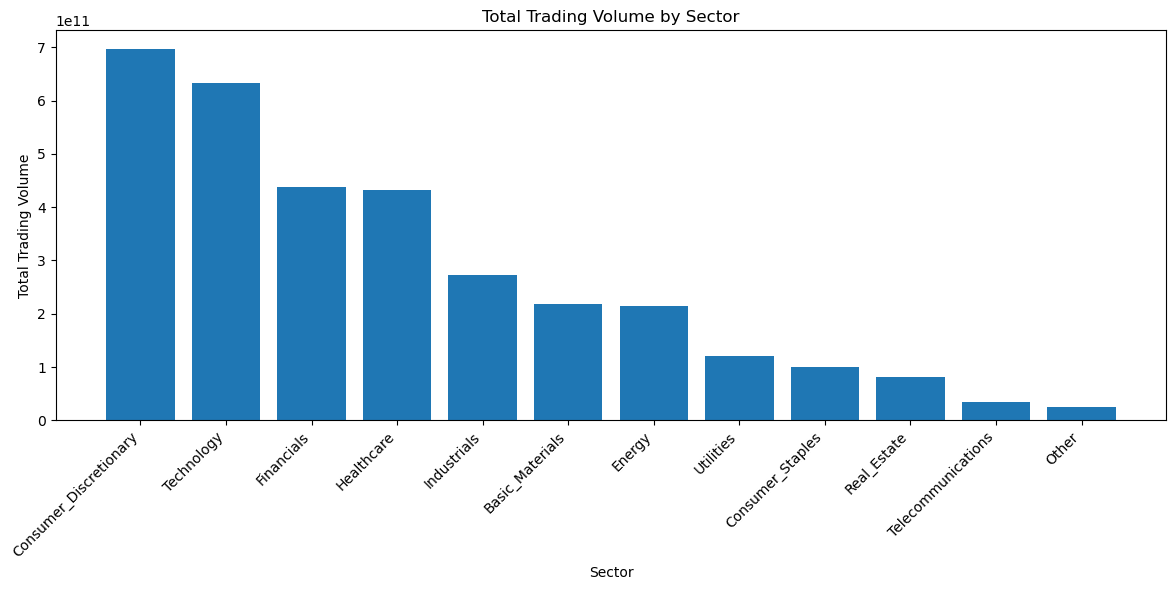

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    sector_pd["sector"],
    sector_pd["total_volume"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Total Trading Volume")
plt.title("Total Trading Volume by Sector")

plt.tight_layout()

plt.savefig(
    FIGURES_ROOT / "total_volume_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

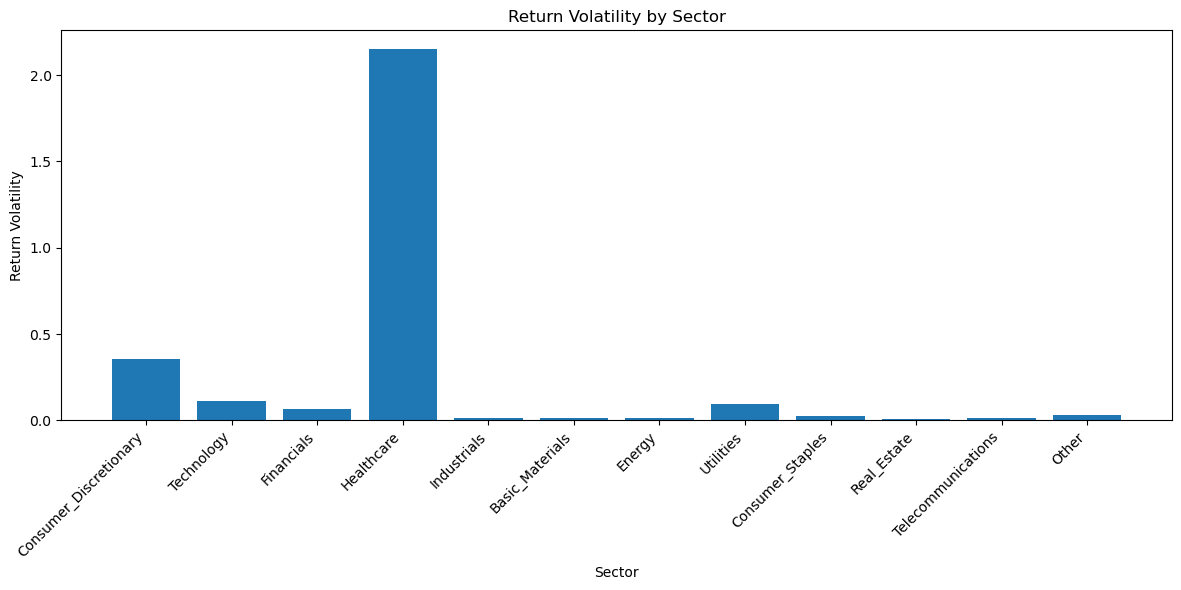

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    sector_pd["sector"],
    sector_pd["return_volatility"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Return Volatility")
plt.title("Return Volatility by Sector")

plt.tight_layout()

plt.savefig(
    FIGURES_ROOT / "return_volatility_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

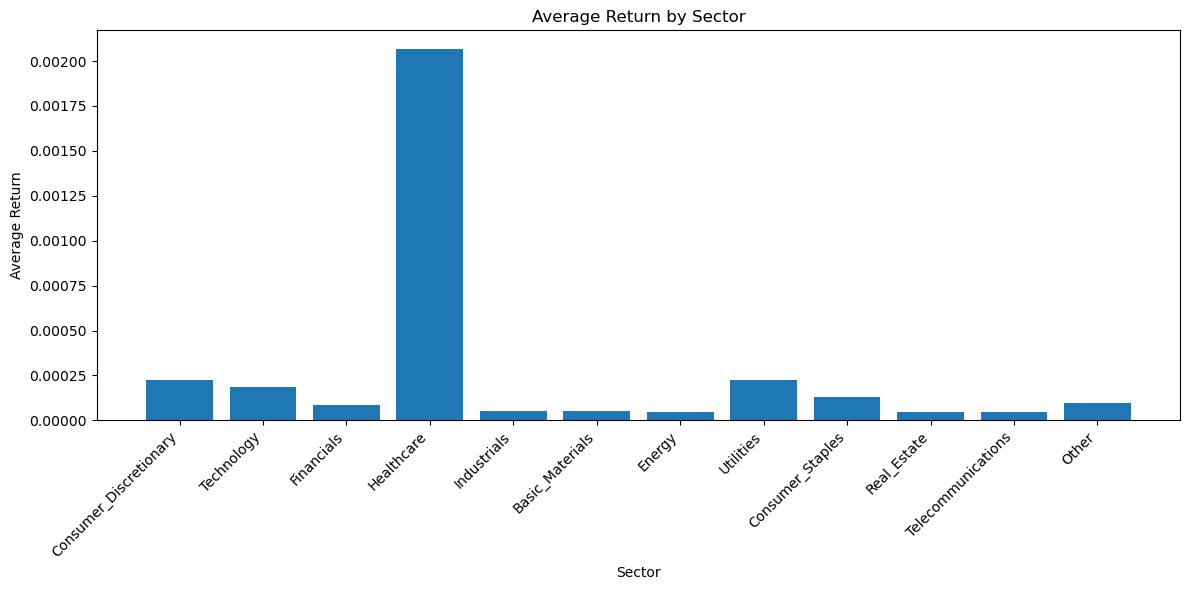

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    sector_pd["sector"],
    sector_pd["average_return"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Sector")
plt.ylabel("Average Return")
plt.title("Average Return by Sector")

plt.tight_layout()

plt.savefig(
    FIGURES_ROOT / "average_return_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
most_active_sector = (
    sector_pd
    .sort_values("total_volume", ascending=False)
    .iloc[0]
)

print("Most active sector:")
print(most_active_sector)

Most active sector:
sector                   Consumer_Discretionary
number_of_stocks                            176
observations                           12240801
average_close                        213.534334
average_volume                     56943.023098
total_volume                     697028214081.0
average_dollar_volume            1852290.321508
total_dollar_volume       22673517219805.976562
average_return                         0.000226
return_volatility                      0.352512
Name: 0, dtype: object


In [ ]:
most_volatile_sector = (
    sector_pd
    .sort_values("return_volatility", ascending=False)
    .iloc[0]
)

print("Most volatile sector:")
print(most_volatile_sector)

Most volatile sector:
sector                              Healthcare
number_of_stocks                           153
observations                           8637654
average_close                      5151.595007
average_volume                    50148.540493
total_volume                    433165741384.0
average_dollar_volume           1523766.921945
total_dollar_volume      13161771448405.351562
average_return                        0.002068
return_volatility                     2.151978
Name: 3, dtype: object


In [ ]:
highest_return_sector = (
    sector_pd
    .sort_values("average_return", ascending=False)
    .iloc[0]
)

print("Highest average return sector:")
print(highest_return_sector)

Highest average return sector:
sector                              Healthcare
number_of_stocks                           153
observations                           8637654
average_close                      5151.595007
average_volume                    50148.540493
total_volume                    433165741384.0
average_dollar_volume           1523766.921945
total_dollar_volume      13161771448405.351562
average_return                        0.002068
return_volatility                     2.151978
Name: 3, dtype: object


In [ ]:
print("=" * 70)
print("PART 2 — KEY RESULTS")
print("=" * 70)

print(
    f"Most active sector: "
    f"{most_active_sector['sector']}"
)

print(
    f"Highest total volume: "
    f"{most_active_sector['total_volume']:,.0f}"
)

print(
    f"Most volatile sector: "
    f"{most_volatile_sector['sector']}"
)

print(
    f"Return volatility: "
    f"{most_volatile_sector['return_volatility']:.6f}"
)

print(
    f"Highest average return sector: "
    f"{highest_return_sector['sector']}"
)

print(
    f"Average return: "
    f"{highest_return_sector['average_return']:.6f}"
)

print("=" * 70)

PART 2 — KEY RESULTS
Most active sector: Consumer_Discretionary
Highest total volume: 697,028,214,081
Most volatile sector: Healthcare
Return volatility: 2.151978
Highest average return sector: Healthcare
Average return: 0.002068


In [ ]:
print("\nTables:")
for file in TABLES_ROOT.iterdir():
    print(" -", file.name)

print("\nFigures:")
for file in FIGURES_ROOT.iterdir():
    print(" -", file.name)


Tables:
 - sector_summary.csv
 - top_10_volatility_stocks.csv
 - top_10_volume_stocks.csv

Figures:
 - average_return_by_sector.png
 - return_volatility_by_sector.png
 - total_volume_by_sector.png


In [ ]:
print("=" * 70)
print("FINAL PART 2 VALIDATION")
print("=" * 70)

print(f"Processing dataset size: {processing_size_gb:.2f} GB")
print(f"Processing files: {len(processing_files):,}")
print(f"Raw observations: {raw_count:,}")
print(f"Clean observations: {clean_count:,}")
print(f"Stocks analysed: {stock_summary_count:,}")
print(f"Sectors analysed: {sector_summary.count():,}")

print("\nSpark:")
print(f"Version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")

print("\nKey result:")
print(f"Most active sector: {most_active_sector['sector']}")
print(f"Most volatile sector: {most_volatile_sector['sector']}")
print(f"Highest average return: {highest_return_sector['sector']}")

print("=" * 70)

FINAL PART 2 VALIDATION
Processing dataset size: 3.05 GB
Processing files: 884
Raw observations: 61,438,865
Clean observations: 61,438,865
Stocks analysed: 884
Sectors analysed: 12

Spark:
Version: 3.5.1
Master: local[*]

Key result:
Most active sector: Consumer_Discretionary
Most volatile sector: Healthcare
Highest average return: Healthcare


In [ ]:
spark.stop()

print("Spark session stopped successfully.")
print("PART 2")

Spark session stopped successfully.
PART 2
